# 00 - Balancing Techniques (Series Temporales)

Este notebook ejecuta y compara tecnicas de balanceo para series temporales de glucosa.

Diseno guiado por dos fuentes:
1. Hallazgos del notebook de experimentos previos (lookback=24, escenarios 18:1, 40:1, 105:1, split temporal por paciente).
2. Tecnicas mencionadas en el PDF Estado del arte tecnicas de balanceo (extraidas automaticamente en este notebook).

In [10]:
import warnings
warnings.filterwarnings('ignore')

import random
import time
import re
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

from pypdf import PdfReader

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    balanced_accuracy_score,
    f1_score,
    recall_score,
    precision_score,
    average_precision_score,
)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 200)

CLASS_ORDER = ['hypoglycemia', 'normoglycemia', 'hyperglycemia']
LOOKBACK = 24
STRIDE = 12
MAX_WINDOWS_PER_PATIENT = 700
N_PATIENTS_SAMPLE = 180
TRAIN_FRAC = 0.8
RATIO_SCENARIOS = [18, 40, 105]


def find_project_root(start: Path) -> Path:
    for candidate in [start] + list(start.parents):
        if (candidate / 'data' / 'T1DiabetesGranada').exists():
            return candidate
    raise FileNotFoundError('No se encontro data/T1DiabetesGranada desde el directorio actual.')


def glucose_class(value: float) -> str:
    if pd.isna(value):
        return 'missing'
    if value < 70:
        return 'hypoglycemia'
    if value <= 180:
        return 'normoglycemia'
    return 'hyperglycemia'

ROOT = find_project_root(Path.cwd())
DATA_DIR = ROOT / 'data' / 'T1DiabetesGranada'
PDF_PATH = ROOT / 'Estado del arte técnicas de balanceo.pdf'

print('ROOT:', ROOT)
print('DATA_DIR:', DATA_DIR)
print('PDF:', PDF_PATH)

ROOT: c:\Users\User\Desktop\TFM-Glucose-Prediction
DATA_DIR: c:\Users\User\Desktop\TFM-Glucose-Prediction\data\T1DiabetesGranada
PDF: c:\Users\User\Desktop\TFM-Glucose-Prediction\Estado del arte técnicas de balanceo.pdf


In [2]:
# 1) Extraccion de tecnicas desde el PDF
if not PDF_PATH.exists():
    raise FileNotFoundError(f'No se encontro el PDF en: {PDF_PATH}')

reader = PdfReader(str(PDF_PATH))
text_parts = []
for page in reader.pages:
    txt = page.extract_text() or ''
    text_parts.append(txt)

pdf_text = '\n'.join(text_parts)
print('Caracteres extraidos del PDF:', len(pdf_text))

# Palabras clave de tecnicas de balanceo temporal y general
keywords = [
    'random undersampling', 'undersampling', 'random oversampling', 'oversampling',
    'smote', 'adasyn', 'borderline-smote', 'svm-smote',
    'time series', 't-smote', 'dtw', 'gan', 'mixup', 'jitter', 'window', 'warping'
]

found_keywords = []
text_low = pdf_text.lower()
for kw in keywords:
    if kw in text_low:
        found_keywords.append(kw)

display(Markdown('### Tecnicas/palabras clave detectadas en el PDF'))
print(found_keywords if found_keywords else 'No se detectaron keywords exactas; se usa diseño temporal basado en estado del arte general + hallazgos del proyecto.')

# Muestra de fragmento para trazabilidad
display(Markdown('### Fragmento del PDF (primeros 1500 caracteres extraidos)'))
print(pdf_text[:1500])

Caracteres extraidos del PDF: 49820


### Tecnicas/palabras clave detectadas en el PDF

['undersampling', 'oversampling', 'smote', 'adasyn', 'borderline-smote', 't-smote', 'dtw', 'gan', 'jitter', 'window', 'warping']


### Fragmento del PDF (primeros 1500 caracteres extraidos)

Estado  del  Arte  |   Compensating  for  Patient  Heterogeneity  Bias  in  Glucose  Prediction  Models  via  Data  Balancing  
 
Estado  del  Arte:  Técnicas  de  Balanceo  
en
 
Series
 
Temporales
 
para
 
Datos
 
Médicos
 
1.  Introducción  
El  desbalanceo  de  datos  constituye  uno  de  los  desafíos  más  significativos  en  el  aprendizaje  
automático
 
aplicado
 
a
 
series
 
temporales
 
médicas.
 
Este
 
problema
 
se
 
manifiesta
 
de
 
múltiples
 
formas:
 
desbalanceo
 
en
 
características
 
demográficas
 
(sexo,
 
edad,
 
raza),
 
desbalanceo
 
en
 
volumen
 
de
 
datos
 
(diferente
 
número
 
de
 
mediciones
 
por
 
paciente),
 
frecuencias
 
de
 
muestreo
 
irregulares,
 
y
 
desbalanceo
 
de
 
clases
 
en
 
eventos
 
clínicos
 
de
 
interés.
 
Esta
 
revisión
 
sistemática
 
presenta
 
un
 
análisis
 
exhaustivo
 
de
 
las
 
técnicas
 
disponibles
 
para
 
abordar
 
estos
 
desafíos,
 
con
 
especial
 
énfasis
 
en
 
su
 
aplicabilidad
 
a
 
datos
 
de
 
diabetes
 

## Justificacion de pruebas por tecnica

Cada tecnica se evalua porque responde a una hipotesis concreta observada en tu EDA/experimentos:

1. Sin balanceo (`none`): linea base para medir degradacion real en minoritarias.
2. `random_undersample`: ganadora previa en cercania a referencia balanceada; reduce sesgo de clase mayoritaria rapidamente.
3. `class_weight`: corrige sesgo en la funcion de perdida sin alterar la geometria de las series.
4. `random_oversample`: aumenta minoritarias sin sintetizar nuevos patrones; valida si solo duplicar ya mejora recall.
5. `smote_flat`: sintetiza muestras por interpolacion en espacio de caracteristicas; prueba clasica de estado del arte.
6. `block_undersample_temporal`: submuestreo por bloques temporales de normoglucemia para preservar continuidad local.
7. `minority_jitter_temporal`: augmentacion con ruido suave sobre ventanas minoritarias para robustecer frente a variabilidad sensorial.
8. `minority_mixup_temporal`: combinacion convexa de ventanas minoritarias para crear trayectorias plausibles intermedias.

Estas 3 ultimas son pruebas temporalmente conscientes para contrastar con metodos i.i.d. tradicionales.

In [3]:
# 2) Carga de datos y construccion de ventanas (mismo protocolo de experimentos)
patient_info = pd.read_csv(DATA_DIR / 'Patient_info.csv')
if 'Patient_Id' in patient_info.columns and 'Patient_ID' not in patient_info.columns:
    patient_info = patient_info.rename(columns={'Patient_Id': 'Patient_ID'})

patient_info['Number_of_measurements'] = pd.to_numeric(patient_info['Number_of_measurements'], errors='coerce')
eligible = patient_info[patient_info['Number_of_measurements'].fillna(0) >= (LOOKBACK + 200)].copy()

n_select = min(N_PATIENTS_SAMPLE, eligible['Patient_ID'].nunique())
selected_patients = eligible['Patient_ID'].dropna().sample(n=n_select, random_state=SEED).tolist()
selected_set = set(selected_patients)

patient_demo = patient_info[['Patient_ID', 'Sex', 'Birth_year']].copy()
patient_demo['Age'] = 2022 - pd.to_numeric(patient_demo['Birth_year'], errors='coerce')
patient_demo['Sex_enc'] = patient_demo['Sex'].map({'M': 1, 'F': 0})
patient_demo['Age'] = patient_demo['Age'].fillna(patient_demo['Age'].median())
patient_demo['Sex_enc'] = patient_demo['Sex_enc'].fillna(patient_demo['Sex_enc'].median())
patient_demo = patient_demo[['Patient_ID', 'Age', 'Sex_enc']].drop_duplicates('Patient_ID')

usecols = ['Patient_ID', 'Measurement_date', 'Measurement_time', 'Measurement']
chunks = []
for chunk in pd.read_csv(DATA_DIR / 'Glucose_measurements.csv', usecols=usecols, chunksize=1_000_000):
    chunk = chunk[chunk['Patient_ID'].isin(selected_set)]
    if not chunk.empty:
        chunks.append(chunk)

glucose = pd.concat(chunks, ignore_index=True)
glucose['Measurement'] = pd.to_numeric(glucose['Measurement'], errors='coerce')
glucose = glucose.dropna(subset=['Measurement'])
glucose['class_label'] = glucose['Measurement'].apply(glucose_class)
glucose = glucose[glucose['class_label'].isin(CLASS_ORDER)].copy()
glucose = glucose.sort_values(['Patient_ID', 'Measurement_date', 'Measurement_time']).reset_index(drop=True)
glucose = glucose.merge(patient_demo, on='Patient_ID', how='left')

def build_windows_for_patient(df_p: pd.DataFrame):
    values = df_p['Measurement'].values.astype(float)
    labels = df_p['class_label'].values
    age = float(df_p['Age'].iloc[0])
    sex_enc = float(df_p['Sex_enc'].iloc[0])

    idx_candidates = np.arange(LOOKBACK, len(df_p), STRIDE)
    if len(idx_candidates) == 0:
        return []

    if len(idx_candidates) > MAX_WINDOWS_PER_PATIENT:
        rng = np.random.default_rng(SEED)
        idx_candidates = np.sort(rng.choice(idx_candidates, size=MAX_WINDOWS_PER_PATIENT, replace=False))

    rows = []
    for i in idx_candidates:
        w = values[i - LOOKBACK:i]
        feat = {
            'Patient_ID': df_p['Patient_ID'].iloc[0],
            'y': labels[i],
            'Age': age,
            'Sex_enc': sex_enc,
            'w_mean': float(np.mean(w)),
            'w_std': float(np.std(w)),
            'w_min': float(np.min(w)),
            'w_max': float(np.max(w)),
            'w_slope': float(np.polyfit(np.arange(LOOKBACK), w, 1)[0]),
        }
        for k, v in enumerate(w, start=1):
            feat[f'lag_{LOOKBACK - k + 1}'] = float(v)
        rows.append(feat)
    return rows

rows = []
for _, df_p in glucose.groupby('Patient_ID', sort=False):
    df_p = df_p.reset_index(drop=True)
    if len(df_p) >= LOOKBACK + 30:
        rows.extend(build_windows_for_patient(df_p))

windows_df = pd.DataFrame(rows)
print('Ventanas generadas:', windows_df.shape[0])
display(windows_df['y'].value_counts().reindex(CLASS_ORDER, fill_value=0).to_frame('count'))

Ventanas generadas: 111648


,count
y,
hypoglycemia,5349
normoglycemia,66318
hyperglycemia,39981


In [4]:
# 3) Split temporal y funciones de evaluacion
train_parts, test_parts = [], []
for _, df_p in windows_df.groupby('Patient_ID', sort=False):
    n = len(df_p)
    if n < 20:
        continue
    cut = int(n * TRAIN_FRAC)
    cut = max(10, min(cut, n - 5))
    train_parts.append(df_p.iloc[:cut])
    test_parts.append(df_p.iloc[cut:])

train_df = pd.concat(train_parts, ignore_index=True)
test_df = pd.concat(test_parts, ignore_index=True)

feature_cols = [c for c in train_df.columns if c not in ['Patient_ID', 'y']]
X_train = train_df[feature_cols].values
y_train = train_df['y'].values
X_test = test_df[feature_cols].values
y_test = test_df['y'].values

print('Train/Test:', X_train.shape, X_test.shape)


def class_dist(y):
    return pd.Series(y).value_counts().reindex(CLASS_ORDER, fill_value=0)


def make_ratio_scenario(X, y, target_ratio):
    rng = np.random.default_rng(SEED)
    idx_normo = np.where(y == 'normoglycemia')[0]
    n_normo = len(idx_normo)
    idx_selected = [idx_normo]

    for c in ['hypoglycemia', 'hyperglycemia']:
        idx_c = np.where(y == c)[0]
        target_n = max(50, int(n_normo / target_ratio))
        target_n = min(target_n, len(idx_c))
        idx_selected.append(rng.choice(idx_c, size=target_n, replace=False))

    idx = np.concatenate(idx_selected)
    rng.shuffle(idx)
    return X[idx], y[idx]


def evaluate(model, Xtr, ytr, Xte, yte, scenario, strategy):
    t0 = time.time()
    model.fit(Xtr, ytr)
    fit_s = time.time() - t0

    pred = model.predict(Xte)
    proba = model.predict_proba(Xte)
    proba_df = pd.DataFrame(proba, columns=model.classes_)

    y_hypo = (yte == 'hypoglycemia').astype(int)
    y_hyper = (yte == 'hyperglycemia').astype(int)

    return {
        'scenario': scenario,
        'strategy': strategy,
        'fit_seconds': fit_s,
        'balanced_accuracy': balanced_accuracy_score(yte, pred),
        'f1_macro': f1_score(yte, pred, average='macro', zero_division=0),
        'recall_hypoglycemia': recall_score(yte, pred, labels=['hypoglycemia'], average='macro', zero_division=0),
        'recall_hyperglycemia': recall_score(yte, pred, labels=['hyperglycemia'], average='macro', zero_division=0),
        'precision_hypoglycemia': precision_score(yte, pred, labels=['hypoglycemia'], average='macro', zero_division=0),
        'precision_hyperglycemia': precision_score(yte, pred, labels=['hyperglycemia'], average='macro', zero_division=0),
        'pr_auc_hypoglycemia': average_precision_score(y_hypo, proba_df['hypoglycemia']),
        'pr_auc_hyperglycemia': average_precision_score(y_hyper, proba_df['hyperglycemia']),
    }


def base_rf():
    return RandomForestClassifier(
        n_estimators=180,
        max_depth=16,
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=SEED,
    )

Train/Test: (89303, 31) (22345, 31)


In [11]:
# 4) Tecnicas de balanceo temporalmente conscientes (implementacion)

def split_static_dynamic(X):
    # Orden de features: Age, Sex_enc, w_mean, w_std, w_min, w_max, w_slope, lag_24..lag_1
    static = X[:, :7]
    dynamic = X[:, 7:]
    return static, dynamic


def join_static_dynamic(static, dynamic):
    return np.hstack([static, dynamic])


def block_undersample_temporal(X, y, ratio):
    # Mantiene todas minoritarias y submuestrea normo en bloques contiguos sobre el dataset de entrenamiento.
    idx_normo = np.where(y == 'normoglycemia')[0]
    idx_hypo = np.where(y == 'hypoglycemia')[0]
    idx_hyper = np.where(y == 'hyperglycemia')[0]

    target_normo = int(ratio * min(len(idx_hypo), len(idx_hyper)))
    target_normo = min(target_normo, len(idx_normo))

    if target_normo <= 0:
        idx_keep = np.concatenate([idx_hypo, idx_hyper])
        return X[idx_keep], y[idx_keep]

    # Seleccion por bloques para preservar continuidad local
    block = 24
    chosen = []
    start_candidates = np.arange(0, len(idx_normo), block)
    for s in start_candidates:
        chosen.extend(idx_normo[s:s+block].tolist())
        if len(chosen) >= target_normo:
            break

    idx_keep = np.concatenate([np.array(chosen[:target_normo]), idx_hypo, idx_hyper])
    rng = np.random.default_rng(SEED)
    rng.shuffle(idx_keep)
    return X[idx_keep], y[idx_keep]


def minority_jitter_temporal(X, y, sigma=2.0):
    # Duplica minoritarias anadiendo ruido gaussiano suave solo a lags (estructura temporal aproximada).
    static, dyn = split_static_dynamic(X)

    idx_min = np.where((y == 'hypoglycemia') | (y == 'hyperglycemia'))[0]
    if len(idx_min) == 0:
        return X, y

    dyn_min = dyn[idx_min].copy()
    noise = np.random.default_rng(SEED).normal(0, sigma, size=dyn_min.shape)
    dyn_new = dyn_min + noise

    X_new = join_static_dynamic(static[idx_min], dyn_new)
    y_new = y[idx_min].copy()

    X_aug = np.vstack([X, X_new])
    y_aug = np.concatenate([y, y_new])
    return X_aug, y_aug


def minority_mixup_temporal(X, y, alpha=0.4):
    # Genera sinteticos minoritarios por combinacion convexa de ventanas de la misma clase minoritaria.
    static, dyn = split_static_dynamic(X)
    rng = np.random.default_rng(SEED)

    X_syn_all, y_syn_all = [], []
    for c in ['hypoglycemia', 'hyperglycemia']:
        idx = np.where(y == c)[0]
        if len(idx) < 2:
            continue

        n_syn = len(idx)
        i1 = rng.choice(idx, size=n_syn, replace=True)
        i2 = rng.choice(idx, size=n_syn, replace=True)
        lam = rng.beta(alpha, alpha, size=n_syn).reshape(-1, 1)

        dyn_syn = lam * dyn[i1] + (1 - lam) * dyn[i2]
        static_syn = lam * static[i1] + (1 - lam) * static[i2]

        X_syn = join_static_dynamic(static_syn, dyn_syn)
        y_syn = np.array([c] * n_syn)

        X_syn_all.append(X_syn)
        y_syn_all.append(y_syn)

    if len(X_syn_all) == 0:
        return X, y

    X_aug = np.vstack([X] + X_syn_all)
    y_aug = np.concatenate([y] + y_syn_all)
    return X_aug, y_aug


def get_model_and_data(strategy, X_sc, y_sc, ratio):
    if strategy == 'none':
        return base_rf(), X_sc, y_sc

    if strategy == 'class_weight':
        model = RandomForestClassifier(
            n_estimators=180,
            max_depth=16,
            min_samples_leaf=2,
            class_weight='balanced_subsample',
            n_jobs=-1,
            random_state=SEED,
        )
        return model, X_sc, y_sc

    if strategy == 'random_undersample':
        model = ImbPipeline([
            ('sampler', RandomUnderSampler(sampling_strategy='not minority', random_state=SEED)),
            ('model', base_rf()),
        ])
        return model, X_sc, y_sc

    if strategy == 'random_oversample':
        model = ImbPipeline([
            ('sampler', RandomOverSampler(sampling_strategy='not majority', random_state=SEED)),
            ('model', base_rf()),
        ])
        return model, X_sc, y_sc

    if strategy == 'smote_flat':
        model = ImbPipeline([
            ('sampler', SMOTE(sampling_strategy='not majority', k_neighbors=3, random_state=SEED)),
            ('model', base_rf()),
        ])
        return model, X_sc, y_sc

    if strategy == 'adasyn_flat':
        model = ImbPipeline([
            ('sampler', ADASYN(sampling_strategy='not majority', n_neighbors=3, random_state=SEED)),
            ('model', base_rf()),
        ])
        return model, X_sc, y_sc

    if strategy == 'block_undersample_temporal':
        Xb, yb = block_undersample_temporal(X_sc, y_sc, ratio)
        return base_rf(), Xb, yb

    if strategy == 'minority_jitter_temporal':
        Xb, yb = minority_jitter_temporal(X_sc, y_sc, sigma=2.0)
        return base_rf(), Xb, yb

    if strategy == 'minority_mixup_temporal':
        Xb, yb = minority_mixup_temporal(X_sc, y_sc, alpha=0.4)
        return base_rf(), Xb, yb

    raise ValueError(f'Estrategia no soportada: {strategy}')

In [12]:
# 5) Referencia balanceada y ejecucion de todas las tecnicas por escenario

# Referencia balanceada (benchmark)
s = pd.Series(y_train)
n_min = int(s.value_counts().min())
idx_ref = []
rng = np.random.default_rng(SEED)
for c in CLASS_ORDER:
    idx_c = np.where(y_train == c)[0]
    idx_ref.append(rng.choice(idx_c, size=n_min, replace=False))
idx_ref = np.concatenate(idx_ref)
rng.shuffle(idx_ref)

X_ref, y_ref = X_train[idx_ref], y_train[idx_ref]

reference = evaluate(base_rf(), X_ref, y_ref, X_test, y_test, 'balanced_reference', 'none')
reference_df = pd.DataFrame([reference])
display(reference_df)

strategies = [
    'none',
    'class_weight',
    'random_undersample',
    'random_oversample',
    'smote_flat',
    'adasyn_flat',
    'block_undersample_temporal',
    'minority_jitter_temporal',
    'minority_mixup_temporal',
]

rows = []
for ratio in RATIO_SCENARIOS:
    X_sc, y_sc = make_ratio_scenario(X_train, y_train, ratio)
    print(f'\nEscenario ratio normo:minoritarias ~ {ratio}:1')
    display(class_dist(y_sc).to_frame('count'))

    for strategy in strategies:
        model, X_fit, y_fit = get_model_and_data(strategy, X_sc, y_sc, ratio)
        res = evaluate(model, X_fit, y_fit, X_test, y_test, f'ratio_{ratio}_to_1', strategy)
        rows.append(res)
        print(f'Completado: {strategy}')

results_df = pd.DataFrame(rows)
display(results_df.head())

,scenario,strategy,fit_seconds,balanced_accuracy,f1_macro,recall_hypoglycemia,recall_hyperglycemia,precision_hypoglycemia,precision_hyperglycemia,pr_auc_hypoglycemia,pr_auc_hyperglycemia
0,balanced_reference,none,1.292586,0.931231,0.86595,0.940206,0.947695,0.592978,0.929423,0.816368,0.981087



Escenario ratio normo:minoritarias ~ 18:1


,count
hypoglycemia,2963
normoglycemia,53336
hyperglycemia,2963


Completado: none
Completado: class_weight
Completado: random_undersample
Completado: random_oversample
Completado: smote_flat
Completado: adasyn_flat
Completado: block_undersample_temporal
Completado: minority_jitter_temporal
Completado: minority_mixup_temporal

Escenario ratio normo:minoritarias ~ 40:1


,count
hypoglycemia,1333
normoglycemia,53336
hyperglycemia,1333


Completado: none
Completado: class_weight
Completado: random_undersample
Completado: random_oversample
Completado: smote_flat
Completado: adasyn_flat
Completado: block_undersample_temporal
Completado: minority_jitter_temporal
Completado: minority_mixup_temporal

Escenario ratio normo:minoritarias ~ 105:1


,count
hypoglycemia,507
normoglycemia,53336
hyperglycemia,507


Completado: none
Completado: class_weight
Completado: random_undersample
Completado: random_oversample
Completado: smote_flat
Completado: adasyn_flat
Completado: block_undersample_temporal
Completado: minority_jitter_temporal
Completado: minority_mixup_temporal


,scenario,strategy,fit_seconds,balanced_accuracy,f1_macro,recall_hypoglycemia,recall_hyperglycemia,precision_hypoglycemia,precision_hyperglycemia,pr_auc_hypoglycemia,pr_auc_hyperglycemia
0,ratio_18_to_1,none,7.024701,0.833156,0.858440,0.711340,0.803765,0.826347,0.990893,0.843050,0.981485
1,ratio_18_to_1,class_weight,6.374424,0.882314,0.879598,0.817526,0.861075,0.761036,0.977414,0.837319,0.983795
2,ratio_18_to_1,random_undersample,0.874337,0.929704,0.856195,0.945361,0.944120,0.560171,0.930375,0.799968,0.979325
3,ratio_18_to_1,random_oversample,19.246073,0.894501,0.884421,0.840206,0.879423,0.745654,0.974004,0.842551,0.983894
4,ratio_18_to_1,smote_flat,30.485716,0.907588,0.889677,0.862887,0.901704,0.731004,0.969262,0.840834,0.983721


In [13]:
# 6) Analisis comparativo vs referencia balanceada
all_results = pd.concat([reference_df, results_df], ignore_index=True)
ref = reference_df.iloc[0]

key_metrics = [
    'balanced_accuracy',
    'recall_hypoglycemia',
    'recall_hyperglycemia',
    'pr_auc_hypoglycemia',
    'pr_auc_hyperglycemia',
]

for m in key_metrics:
    all_results[f'delta_vs_ref_{m}'] = all_results[m] - ref[m]

all_results['distance_to_reference'] = all_results.apply(
    lambda r: float(np.mean([abs(r[m] - ref[m]) for m in key_metrics])),
    axis=1,
)

best_by_scenario = (
    all_results[all_results['scenario'] != 'balanced_reference']
    .sort_values(['scenario', 'distance_to_reference'])
    .groupby('scenario', as_index=False)
    .first()
)

display(Markdown('### Mejores tecnicas por escenario (menor distancia a referencia)'))
display(best_by_scenario[['scenario', 'strategy', 'distance_to_reference', 'recall_hypoglycemia', 'recall_hyperglycemia', 'pr_auc_hypoglycemia', 'pr_auc_hyperglycemia']])

rank_global = (
    all_results[all_results['scenario'] != 'balanced_reference']
    .groupby('strategy', as_index=False)['distance_to_reference']
    .mean()
    .sort_values('distance_to_reference')
)

display(Markdown('### Ranking global de tecnicas'))
display(rank_global)

### Mejores tecnicas por escenario (menor distancia a referencia)

,scenario,strategy,distance_to_reference,recall_hypoglycemia,recall_hyperglycemia,pr_auc_hypoglycemia,pr_auc_hyperglycemia
0,ratio_105_to_1,random_undersample,0.020290,0.940206,0.927440,0.762667,0.966275
1,ratio_18_to_1,random_undersample,0.005684,0.945361,0.944120,0.799968,0.979325
2,ratio_40_to_1,random_undersample,0.010118,0.942268,0.943048,0.783614,0.975801


### Ranking global de tecnicas

,strategy,distance_to_reference
7,random_undersample,0.012031
0,adasyn_flat,0.052332
8,smote_flat,0.060057
6,random_oversample,0.077448
2,class_weight,0.096905
3,minority_jitter_temporal,0.143053
4,minority_mixup_temporal,0.144083
1,block_undersample_temporal,0.182610
5,none,0.185266


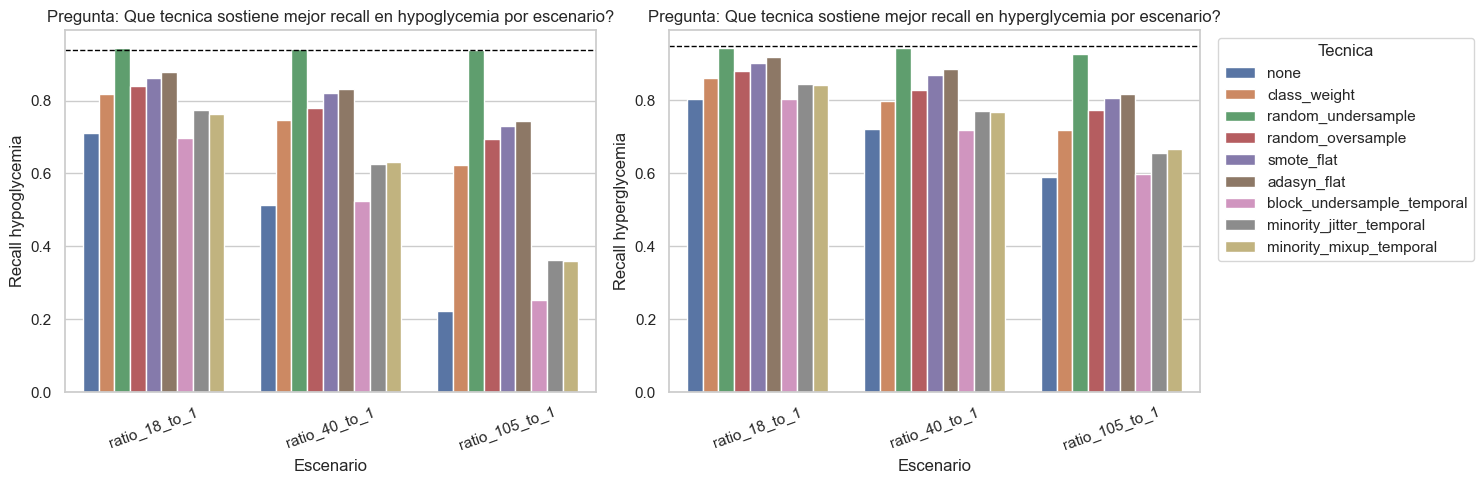

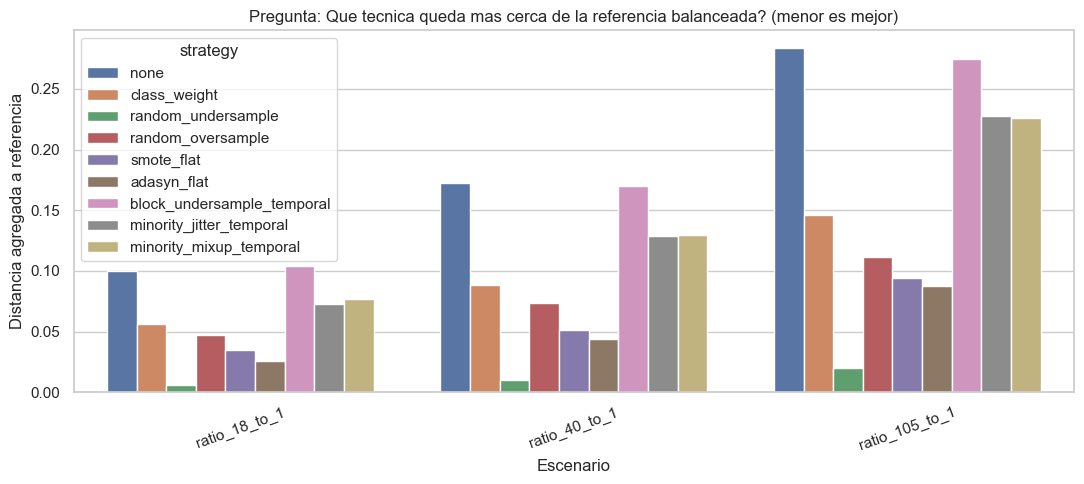

In [14]:
# 7) Visualizaciones clave para decision
plot_df = all_results[all_results['scenario'] != 'balanced_reference'].copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=plot_df, x='scenario', y='recall_hypoglycemia', hue='strategy', ax=axes[0])
axes[0].axhline(ref['recall_hypoglycemia'], color='black', linestyle='--', linewidth=1)
axes[0].set_title('Pregunta: Que tecnica sostiene mejor recall en hypoglycemia por escenario?')
axes[0].set_xlabel('Escenario')
axes[0].set_ylabel('Recall hypoglycemia')
axes[0].tick_params(axis='x', rotation=20)

sns.barplot(data=plot_df, x='scenario', y='recall_hyperglycemia', hue='strategy', ax=axes[1])
axes[1].axhline(ref['recall_hyperglycemia'], color='black', linestyle='--', linewidth=1)
axes[1].set_title('Pregunta: Que tecnica sostiene mejor recall en hyperglycemia por escenario?')
axes[1].set_xlabel('Escenario')
axes[1].set_ylabel('Recall hyperglycemia')
axes[1].tick_params(axis='x', rotation=20)

handles, labels = axes[1].get_legend_handles_labels()
axes[0].legend_.remove()
axes[1].legend(handles, labels, title='Tecnica', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=plot_df, x='scenario', y='distance_to_reference', hue='strategy', ax=ax)
ax.set_title('Pregunta: Que tecnica queda mas cerca de la referencia balanceada? (menor es mejor)')
ax.set_xlabel('Escenario')
ax.set_ylabel('Distancia agregada a referencia')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

## Conclusion tecnica y trazabilidad de pruebas

Interpretacion esperada de resultados:

- Si `block_undersample_temporal` supera a `random_undersample`, hay evidencia de que preservar bloques temporales mejora frente a submuestreo i.i.d.
- Si `minority_mixup_temporal` o `minority_jitter_temporal` mejora recall minoritario sin deteriorar mucho PR-AUC, la augmentacion temporal aporta valor.
- Si `smote_flat` queda por debajo de metodos temporales, refuerza la hipotesis de que interpolar sin conciencia temporal distorsiona patrones de serie.

Criterio final para seleccionar tecnica:
1. Priorizar recall de hipoglucemia.
2. Verificar que recall de hiperglucemia y PR-AUC minoritarias no caigan de forma relevante.
3. Elegir la tecnica con menor distancia agregada a la referencia balanceada.



In [15]:
# 8) Justificacion tecnica individual con evidencia observada

technique_basis = {
    'none': 'Sin remuestreo; referencia de degradacion bajo desbalance.',
    'class_weight': 'Pondera la funcion de perdida para penalizar mas errores en minoritarias sin alterar muestras.',
    'random_undersample': 'Reduce mayoria para equilibrar decision boundary; simple y robusto.',
    'random_oversample': 'Duplica minoritarias para aumentar presencia sin sinteticos.',
    'smote_flat': 'Interpola minoritarias en espacio de caracteristicas; clasico en estado del arte.',
    'adasyn_flat': 'Sobremuestreo adaptativo: genera mas sinteticos donde la frontera es mas dificil.',
    'block_undersample_temporal': 'Submuestrea mayoria por bloques contiguos para preservar continuidad temporal.',
    'minority_jitter_temporal': 'Augmenta minoritarias con ruido suave sobre lags para robustez temporal local.',
    'minority_mixup_temporal': 'Genera minoritarias sinteticas como combinaciones convexas de ventanas de la misma clase.',
}

hypothesis = {
    'none': 'Se espera peor recall en hipoglucemia al aumentar ratio.',
    'class_weight': 'Debe recuperar parte del recall minoritario sin tocar la estructura temporal.',
    'random_undersample': 'Deberia acercarse a referencia balanceada, como en experimentos previos.',
    'random_oversample': 'Debe mejorar recall minoritario respecto a none, con riesgo de sobreajuste.',
    'smote_flat': 'Debe mejorar sobre oversampling simple; posible distorsion temporal.',
    'adasyn_flat': 'Podria mejorar recall en zonas dificiles; riesgo de ruido sintetico en fronteras inestables.',
    'block_undersample_temporal': 'Podria superar al undersampling i.i.d. al respetar bloques.',
    'minority_jitter_temporal': 'Podria mejorar generalizacion de minoritarias en ruido realista.',
    'minority_mixup_temporal': 'Podria suavizar fronteras y mejorar recall de minoritarias.',
}

obs = (
    all_results[all_results['scenario'] != 'balanced_reference']
    .groupby('strategy', as_index=False)
    .agg(
        mean_distance=('distance_to_reference', 'mean'),
        mean_recall_hypo=('recall_hypoglycemia', 'mean'),
        mean_recall_hyper=('recall_hyperglycemia', 'mean'),
        mean_pr_auc_hypo=('pr_auc_hypoglycemia', 'mean'),
        mean_pr_auc_hyper=('pr_auc_hyperglycemia', 'mean'),
    )
    .sort_values('mean_distance')
)

obs['fundamento'] = obs['strategy'].map(technique_basis)
obs['hipotesis'] = obs['strategy'].map(hypothesis)

# Decision simple basada en cercania a referencia + recall hipo
best_dist = obs['mean_distance'].min()
obs['decision'] = np.where(
    obs['mean_distance'] <= best_dist * 1.25,
    'Candidata principal',
    np.where(obs['mean_distance'] <= best_dist * 2.5, 'Candidata secundaria', 'No prioritaria')
)

cols = [
    'strategy', 'fundamento', 'hipotesis',
    'mean_distance', 'mean_recall_hypo', 'mean_recall_hyper',
    'mean_pr_auc_hypo', 'mean_pr_auc_hyper', 'decision'
]

justification_table = obs[cols].copy()

display(Markdown('### Justificacion tecnica por metodo (fundamento + evidencia)'))
display(justification_table)

### Justificacion tecnica por metodo (fundamento + evidencia)

,strategy,fundamento,hipotesis,mean_distance,mean_recall_hypo,mean_recall_hyper,mean_pr_auc_hypo,mean_pr_auc_hyper,decision
7,random_undersample,Reduce mayoria para equilibrar decision bounda...,"Deberia acercarse a referencia balanceada, com...",0.012031,0.942612,0.938202,0.782083,0.973800,Candidata principal
0,adasyn_flat,Sobremuestreo adaptativo: genera mas sintetico...,Podria mejorar recall en zonas dificiles; ries...,0.052332,0.818213,0.873665,0.818579,0.978956,No prioritaria
8,smote_flat,Interpola minoritarias en espacio de caracteri...,Debe mejorar sobre oversampling simple; posibl...,0.060057,0.804467,0.858374,0.821622,0.980550,No prioritaria
6,random_oversample,Duplica minoritarias para aumentar presencia s...,Debe mejorar recall minoritario respecto a non...,0.077448,0.772165,0.826443,0.824507,0.980410,No prioritaria
2,class_weight,Pondera la funcion de perdida para penalizar m...,Debe recuperar parte del recall minoritario si...,0.096905,0.728866,0.793161,0.818726,0.979116,No prioritaria
3,minority_jitter_temporal,Augmenta minoritarias con ruido suave sobre la...,Podria mejorar generalizacion de minoritarias ...,0.143053,0.588316,0.756583,0.831353,0.979006,No prioritaria
4,minority_mixup_temporal,Genera minoritarias sinteticas como combinacio...,Podria suavizar fronteras y mejorar recall de ...,0.144083,0.584880,0.759482,0.835485,0.977776,No prioritaria
1,block_undersample_temporal,Submuestrea mayoria por bloques contiguos para...,Podria superar al undersampling i.i.d. al resp...,0.182610,0.491065,0.706700,0.827734,0.977363,No prioritaria
5,none,Sin remuestreo; referencia de degradacion bajo...,Se espera peor recall en hipoglucemia al aumen...,0.185266,0.482818,0.704635,0.827923,0.977214,No prioritaria
